<a href="https://colab.research.google.com/github/hmmnyamminji/python/blob/main/Chapter09_%EC%B6%94%EC%B2%9C%EC%8B%9C%EC%8A%A4%ED%85%9C_%EC%8B%A4%EC%8A%B5(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive


Saving NanumGothic.ttf to NanumGothic.ttf


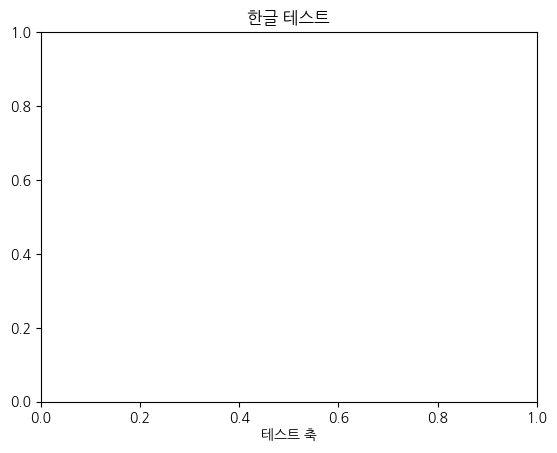

In [ ]:
from google.colab import drive, files
drive.mount('/content/drive')

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.cm as cm # 컬러맵(colormap)
import matplotlib.font_manager as fm
import shutil, os

uploaded = files.upload()
font_dst = '/usr/local/share/fonts/NanumGothic.ttf'
os.makedirs('/usr/local/share/fonts', exist_ok=True)
shutil.copy('NanumGothic.ttf', font_dst)

fm.fontManager.ttflist = [
    f for f in fm.fontManager.ttflist
    if '/content/drive' not in f.fname
]

fm.fontManager.addfont(font_dst)
mpl.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots()
ax.set_title('한글 테스트')
ax.set_xlabel('테스트 축')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

### 잠재 요인 협업 필터링 - 경사 하강법 행렬 분해
행렬 분해(Matrix Factorization) 기반 추천 시스템 개념

[추천 시스템의 핵심 문제]
* 사용자-아이템 평점 행렬 R에서 대부분의 값이 NaN (미평가)
* NaN 위치의 평점을 예측해 높은 점수의 아이템을 추천

R ≈ P × Qᵀ
사용자 잠재 요인(P)과 아이템 잠재 요인(Q)으로 평점 행렬 분해

SGD로 P, Q를 반복 업데이트하여 예측 오류 최소화

[잠재 요인(Latent Factor)이란?]
* 명시적으로 정의되지 않은 숨겨진 특성
* 예: 영화의 경우 → 액션성, 로맨틱함, 코미디 요소 등
* 사용자는 자신의 취향(P), 아이템은 특성(Q)을 K차원으로 표현
* P × Qᵀ 내적 → 사용자-아이템 선호도 점수(예측 평점) 계산

[행렬 분해란?]
R ≈ P × Qᵀ
* R: (사용자 × 아이템) 원본 평점 행렬 (NaN 다수)
* P: (사용자 × K) 사용자 잠재 요인 행렬
* Q: (아이템 × K) 아이템 잠재 요인 행렬
* K: 잠재 요인(Latent Factor) 차원 수

In [ ]:
#원본 평점 행렬 R 생성, 행 : 사용자 4명, 열: 아이템5개, NaN : 미평가 항목 -> 이 값을 예측하는 것이 목표
R = np.array([[4, np.nan, np.nan, 2, np.nan],
              [np.nan, 5, np.nan, 3, 1],
              [np.nan, np.nan, 3, 4, 4],
              [5, 2, 1, 2, np.nan]])
num_users, num_items = R.shape#(4,5)
K = 3 #잠재 요인 차원 수(하이퍼파라미터), 너무 크면 : 과적합, 실제 Netflex prize 우승 모델 : k-200 이상 사용
np.random.seed(1)
P = np.random.normal(scale=1./K, size=(num_users, K))#정규분포(scale=1/K)로 작은 값으로 초기화
Q = np.random.normal(scale=1./K, size=(num_items, K))#너무 큰 초기값은 SGD 초기 단계에서 발산 위험
#SGD(확률적 경사 하강법)는 모델의 에측 오차를 줄이기 위해 P와 Q행렬을 조금씩(확률적으로)업데이트하는 최적화 방법
#목표는 실제 평점과 에측 평점 사이의 차이를 최소화하는 것
print('R shape:', R.shape)
print('P shape:', P.shape)
print('Q shape:', Q.shape)


R shape: (4, 5)
P shape: (4, 3)
Q shape: (5, 3)
